## **Load Data**
#### (Paste Directory here)

In [2]:
from SlideBook_API import SlideBookImageDir
imgdir = r'C:\Users\nick1\Desktop\2P_image\20260331_DCN_8S\Slide1.dir\WF_10_45_100_3(1)-1774965321-85.imgdir'
img_data = SlideBookImageDir(imgdir)

## **Create Output Path**

In [3]:
from pathlib import Path
import re

def create_clean_analyzed_path(imgdir_path):
    imgdir_path = Path(imgdir_path).resolve()

    if not imgdir_path.exists():
        raise FileNotFoundError(f"{imgdir_path} does not exist")

    # imgdir folder name cleanup
    img_name = imgdir_path.name
    img_name = img_name.replace(".imgdir", "")
    # img_name = img_name.split("-")[0]  # keep only meaningful part

    # Slide folder cleanup
    slide_dir = imgdir_path.parent
    slide_name = slide_dir.name.replace(".dir", "")

    # Main folder
    main_folder = slide_dir.parent

    # Construct analyzed output path
    analyzed_path = main_folder / 'Analyzed' / slide_name / img_name
    analyzed_path.mkdir(parents=True, exist_ok=True)

    return analyzed_path

output_path = create_clean_analyzed_path(imgdir)

## **Information Extraction**

In [4]:
import numpy as np
from pathlib import Path
import os
import dask.array as da
from dask import delayed

elapsed_times = np.array(img_data.ElapsedTimes['theElapsedTimes'][1:], dtype=np.int64)
scale = (img_data.MicronPerPixel, img_data.MicronPerPixel)
channels = img_data.Images

# =============Specific for WF==============================
WFimage_name = 'ImageData_Ch0'

WFimgdir_list = sorted(
    [p.name for p in img_data.path.iterdir()
     if p.name.startswith(WFimage_name)]
)

# --- get shape from first frame ---
first = np.load(os.path.join(img_data.path, WFimgdir_list[0]), mmap_mode='r')
Y, X = first.squeeze(0).shape

def load_frame(path):
    return np.load(path, mmap_mode='r').squeeze(0)

lazy_arrays = [
    da.from_delayed(
        delayed(load_frame)(os.path.join(img_data.path, fname)),
        shape=(Y, X),
        dtype=first.dtype,
    )
    for fname in WFimgdir_list
]

channels['Green'] = da.stack(lazy_arrays, axis=0)

In [5]:
print(f'{len(elapsed_times)/(elapsed_times[-1]/1000)}Hz')

10.057663939922222Hz


# **=============Preprocess Section=============**

## **Build Reference Frame**

In [6]:
import numpy as np
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

movie = channels['Green']
T, Y, X = movie.shape

reference_mode = 0   # or "mean"
template_sigma = 1.0

if reference_mode == "mean":
    template = np.zeros((Y, X), dtype=np.float64)
    for t in tqdm(range(T), desc="Building mean reference"):
        template += movie[t].compute()
    template /= T
elif isinstance(reference_mode, int):
    template = movie[reference_mode].compute()
else:
    raise ValueError

template = gaussian_filter(template.astype(np.float32), sigma=template_sigma)


## **Compute Background From Sample**
#### **Estimate a 2D background intensity based on the percentile of each pixel across time and smooth it with guassian filter**

In [7]:
percentile = 5
sigma_bg = 8
n_samples = min(500, T)

rng = np.random.default_rng(0)
idx = rng.choice(T, size=n_samples, replace=False)

sample = np.empty((n_samples, Y, X), dtype=np.float32)

for i, t in enumerate(tqdm(idx, desc="Sampling for background")):
    sample[i] = movie[t].compute()

F0 = np.percentile(sample, percentile, axis=0)
background = gaussian_filter(F0, sigma=sigma_bg)


Sampling for background: 100%|██████████| 150/150 [00:01<00:00, 90.50it/s]


## **Full Streaming Preprocess + Save (Single Pass)**

In [8]:
import os
from scipy.ndimage import shift, gaussian_filter
from skimage.registration import phase_cross_correlation

sigma_xy = 0.5
upsample_factor = 10

out_path = os.path.join(output_path, "Preprocessed.npy")
os.makedirs(output_path, exist_ok=True)

mm = np.lib.format.open_memmap(
    out_path,
    mode="w+",
    dtype=np.float32,
    shape=(T, Y, X),
)

for t in tqdm(range(T), desc="Full preprocessing"):
    
    # ---- Load one frame ----
    frame = movie[t].compute().astype(np.float32)

    # ---- Motion correction ----
    shift_est, _, _ = phase_cross_correlation(
        template,
        frame,
        upsample_factor=upsample_factor,
    )

    frame = shift(
        frame,
        shift=shift_est,
        order=1,
        mode="constant",
        cval=0,
        prefilter=False,
    )

    # ---- Background removal ----
    frame -= background
    np.maximum(frame, 0, out=frame)

    # ---- Spatial denoise ----
    gaussian_filter(
        frame,
        sigma=sigma_xy,
        output=frame,
    )

    # ---- Write directly to disk ----
    mm[t] = frame

del mm

print("Preprocessing complete and saved.")


Full preprocessing:  31%|███       | 46/150 [00:03<00:08, 12.08it/s]c:\Users\nick1\anaconda3\envs\cellpose-napari\lib\site-packages\skimage\registration\_phase_cross_correlation.py:119: RuntimeWarning: overflow encountered in scalar multiply
  amp = src_amp * target_amp
Full preprocessing: 100%|██████████| 150/150 [00:12<00:00, 11.90it/s]

Preprocessing complete and saved.


## **Preprocessed I/O**

In [9]:
channels['Green'] = np.load(
    os.path.join(output_path, "Preprocessed.npy"),
    mmap_mode="r"
)


## **Open Viewer**
#### (With Loaded Channels)

In [10]:
import napari

viewer = napari.Viewer()

for channel_key, channel_array in channels.items():
    viewer.add_image(
        channel_array,
        name=channel_key,
        colormap=channel_key,
        blending='additive',
        scale=scale,
    )


## **Add Scalebar**

In [14]:
viewer.scale_bar.visible = True

# Text options
viewer.scale_bar.unit = 'um'  # set to None to diplay no unit
viewer.scale_bar.length = 50 # length, in units, of the scale bar
viewer.scale_bar.font_size = 10 # default is 10

# Text color
viewer.scale_bar.colored = True  # default value is False
viewer.scale_bar.color = 'white'  # default value is magenta: (1,0,1,1)

# Background box
viewer.scale_bar.box = False  # add background box, default is False
viewer.scale_bar.box_color = (0, 1, 1, 0.2)  # cyan with alpha=0.2

# Scale bar position
viewer.scale_bar.position = 'bottom_center'  # default is 'bottom_right'

# **============ROI Drawing==============**

## **Create Blank 2D Labeling Layer**

In [8]:
IMG_LAYER = 'Green'

img = viewer.layers[IMG_LAYER]
H, W = img.data.shape[-2], img.data.shape[-1]

labels2d = np.zeros((H, W), dtype=np.uint16)

scale_2d     = tuple(np.atleast_1d(getattr(img, 'scale',     (1, 1)))[-2:])
translate_2d = tuple(np.atleast_1d(getattr(img, 'translate', (0, 0)))[-2:])

lab = viewer.add_labels(
    labels2d,
    name='ROI 2D',
    opacity=0.7,
    scale=scale_2d,
    translate=translate_2d,
)

## **Output Label Layer(mask) as npy**

In [9]:
lab = viewer.layers['ROI 2D']
IMG_LAYER = 'Green'

save_obj = {
    'mask': lab.data.astype(np.uint16),
    'scale': tuple(np.atleast_1d(getattr(lab, 'scale', (1, 1)))),
    'translate': tuple(np.atleast_1d(getattr(lab, 'translate', (0, 0)))),
    'base_layer': IMG_LAYER, 
    'img_hw': viewer.layers[IMG_LAYER].data.shape[-2:]
}

np.save(f'{output_path}/ROI_labels.npy', save_obj, allow_pickle=True)
print('Saved: mask + transform -> ROI_labels.npy')

Saved: mask + transform -> ROI_labels.npy


## **Load Exisisting Mask File**

In [10]:
IMG_LAYER = 'Green'
loaded = np.load(f'{output_path}/ROI_labels.npy', allow_pickle=True).item()
# loaded = np.load(r'C:\Users\nick1\Desktop\2P_image\Debi_Data\Analyzed\Slide\Streamtodisk-1769166699-997\ROI_labels.npy', allow_pickle=True).item()

mask = loaded.get('mask')
scale_2d = tuple(loaded.get('scale', (1, 1)))
trans_2d = tuple(loaded.get('translate', (0, 0)))

img = viewer.layers[IMG_LAYER]
H, W = img.data.shape[-2], img.data.shape[-1]

if mask.shape == (W, H):
    mask = mask.T

if mask.shape != (H, W):
    new_mask = np.zeros((H, W), dtype=np.uint16)
    h = min(H, mask.shape[0]); w = min(W, mask.shape[1])
    new_mask[:h, :w] = mask[:h, :w]
    mask = new_mask

lab_loaded = viewer.add_labels(
    mask,
    name='Manual ROI (loaded)',
    opacity=0.7,
    scale=scale_2d,
    translate=trans_2d,
)

# **=================Plotting=======================**

## **Raw Calcium Trace**

In [11]:
import os
import numpy as np
from tqdm import tqdm

def extract_raw_traces_streaming(Gchannel, mask, output_path):
    """
    Extract ROI traces safely from Dask or memmap movie.
    Works frame-by-frame to avoid OOM.
    """

    os.makedirs(output_path, exist_ok=True)

    T, Y, X = Gchannel.shape

    # ---- ensure mask shape ----
    if mask.shape == (X, Y):
        mask = mask.T
    if mask.shape != (Y, X):
        fixed = np.zeros((Y, X), dtype=mask.dtype)
        h, w = min(Y, mask.shape[0]), min(X, mask.shape[1])
        fixed[:h, :w] = mask[:h, :w]
        mask = fixed

    roi_ids = [r for r in np.unique(mask) if r != 0]

    # Precompute pixel indices for each ROI (important optimization)
    roi_indices = {
        roi_id: np.where(mask == roi_id)
        for roi_id in roi_ids
    }

    # Initialize trace storage
    traces = {
        roi_id: np.zeros(T, dtype=np.float32)
        for roi_id in roi_ids
    }

    # ---- streaming over frames ----
    for t in tqdm(range(T), desc="Extracting ROI traces"):
        frame = Gchannel[t]

        # If Dask → compute only one frame
        if hasattr(frame, "compute"):
            frame = frame.compute()

        for roi_id in roi_ids:
            yy, xx = roi_indices[roi_id]
            traces[roi_id][t] = frame[yy, xx].mean()

    # ---- save traces ----
    for roi_id in roi_ids:
        np.save(
            os.path.join(output_path, f"Raw_trace_ROI{roi_id}.npy"),
            traces[roi_id]
        )

    print(f"Saved {len(roi_ids)} ROI traces to {output_path}")
    
extract_raw_traces_streaming(viewer.layers['Green'].data, mask, f'{output_path}/All_ROI_Traces')

Extracting ROI traces: 100%|██████████████████████████████████████████████████████| 3254/3254 [00:04<00:00, 701.18it/s]

Saved 2 ROI traces to C:\Users\nick1\Desktop\2P_image\Debi_Data\Analyzed\Slide\leftdrg_wf_duringsnicut_10s-1769587313-800/All_ROI_Traces


## **Produce df/f trace**

In [14]:
elapsed_times

array([     0,    105,    209, ..., 337733, 337837, 339207], shape=(3254,))

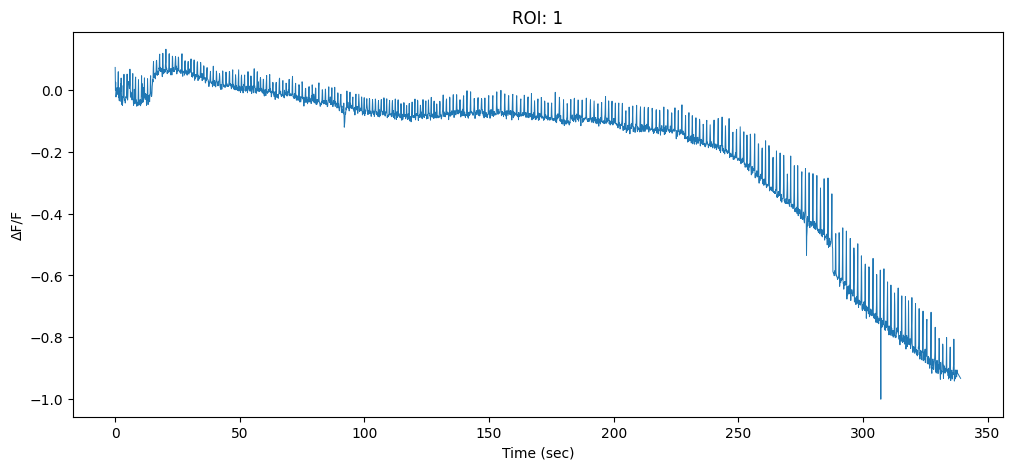

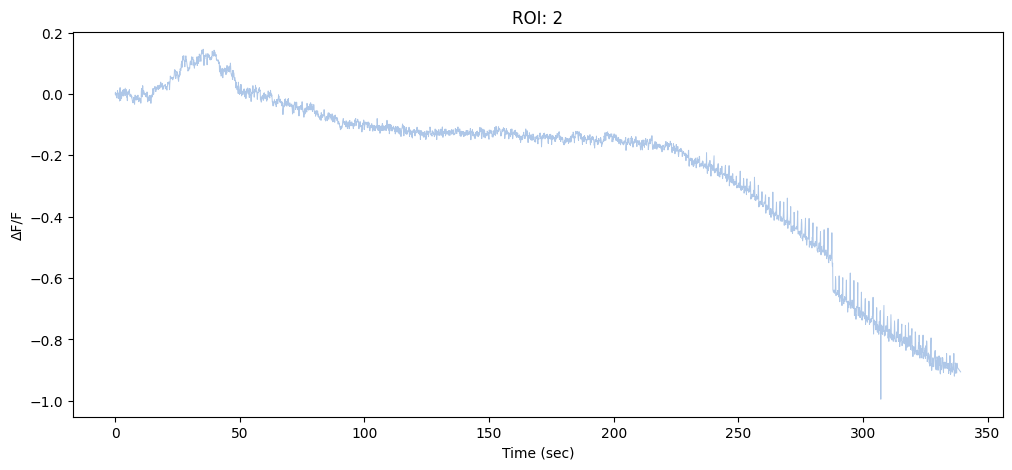

In [12]:
import matplotlib.pyplot as plt

roi_ids = [r for r in np.unique(mask) if r != 0]
roi_traces = {}
for roi_id in roi_ids:
    raw_trace = np.load(f'{output_path}/All_ROI_Traces/Raw_trace_ROI{roi_id}.npy')
    # baseline_idx = np.where((elapsed_times >= 300295)|(elapsed_times <= 1000))[0] 
    baseline_idx = np.where(elapsed_times<=2000)[0] 
    if len(baseline_idx) == 0:
        raise ValueError("Time range not exist in elapsed_times")
    f0 = raw_trace[baseline_idx].mean() 

        # 避免 f0 為 0 時除以 0
    if f0 == 0:
        dff = np.zeros_like(raw_trace, dtype=float)
    else:
        dff = (raw_trace - f0) / f0
    roi_traces[roi_id] = dff

time = elapsed_times / 1000

cmap = plt.get_cmap('tab20')      
T = next(iter(roi_traces.values())).shape[0]  

for roi_id, dff in roi_traces.items():
    plt.figure(figsize=(12, 5))
    plt.plot(time, dff, label=f'ROI {roi_id}', linewidth=0.7, color=cmap((roi_id-1)%10))
    plt.xlabel("Time (sec)")
    plt.ylabel("ΔF/F")
    plt.title(f'ROI: {roi_id}')
    plt.savefig(f'{output_path}/All_ROI_Traces/Calcium_Trace_ROI[{roi_id}].png', dpi=150)
    np.save(f'{output_path}/All_ROI_Traces/Calcium_Trace_ROI[{roi_id}].npy', dff)
    plt.show()

## **Save ROI Picture**

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def save_roi_overlay_image(
    image_2d_name,              # (Y, X) — max projection or any 2D frame
    label_2d_name,              # (Y, X) — ROI labels (same as video)
    out_path,              # "output.png"
    roi_label_map=None,    # optional {roi_id : "B1", ...}
    roi_prefix="ROI ",
    figsize=(6,6),
):
    image_2d = viewer.layers[image_2d_name].data
    label_2d = viewer.layers[label_2d_name].data
    Y, X = image_2d.shape

    # Fix label orientation if needed
    if label_2d.shape == (X, Y):
        label_2d = label_2d.T

    # Identify ROIs
    roi_ids = np.unique(label_2d)
    roi_ids = roi_ids[roi_ids != 0]

    # Precompute contours + centers
    contours = {}
    centers = {}
    for rid in roi_ids:
        m = (label_2d == rid).astype(np.uint8)
        cs = measure.find_contours(m, level=0.5)
        contours[rid] = cs

        ys, xs = np.nonzero(m)
        if len(ys) > 0:
            centers[rid] = (ys.mean(), xs.mean())
        else:
            centers[rid] = (Y/2, X/2)

    # Contrast normalization
    layer = viewer.layers[image_2d_name]
    vmin, vmax = layer.contrast_limits
    frame_norm = np.clip((image_2d - vmin) / (vmax - vmin + 1e-9), 0, 1)

    cmap = plt.get_cmap("tab10")

    # Create clean borderless figure
    fig = plt.figure(figsize=figsize, dpi=120)
    fig.patch.set_facecolor("black")
    ax = fig.add_axes([0,0,1,1])
    ax.set_axis_off()

    ax.imshow(frame_norm, cmap="gray", vmin=0, vmax=1, interpolation="nearest")

    # Draw ROIs
    for idx, rid in enumerate(roi_ids):
        color = cmap(idx % 10)
        for poly in contours[rid]:
            ax.plot(poly[:,1], poly[:,0], linewidth=0.6, color=color)

        cy, cx = centers[rid]
        label_text = (
            roi_label_map[rid]
            if (roi_label_map and rid in roi_label_map)
            else f"{roi_prefix}{rid}"
        )

        ax.text(cx, cy, label_text, color="black",
                fontsize=7, ha="center", va="center", weight="bold")
        ax.text(cx, cy, label_text, color="yellow",
                fontsize=7, ha="center", va="center", weight="bold")

    # Save image
    fig.savefig(out_path, dpi=200, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    print(f"Saved labeled overlay image → {out_path}")

image_2d = "Green std-proj"
label_2d = "Manual ROI (loaded)"

save_roi_overlay_image(image_2d, label_2d, f"{output_path}/ROI_Labeled.png")

Saved labeled overlay image → C:\Users\nick1\Desktop\2P_image\Debi_Data\Analyzed\Slide\leftdrg_wf_duringsnicut_10s-1769587313-800/ROI_Labeled.png


# **=============Post Analysis Section================**
### Run it once the calcium trace is created

## **1. Load Calcium Traces**

In [65]:
save_path = r'C:\Users\nick1\Desktop\2P_image\Debi_Data\Analyzed\Slide\Streamtodisk-1769166699-997\Cluster_Organized'

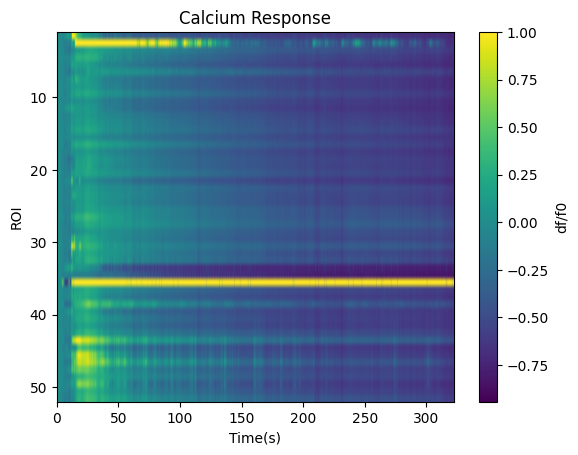

In [16]:
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

analyzed_folder = Path(r'C:\Users\nick1\Desktop\2P_image\Debi_Data\Analyzed\Slide\Streamtodisk-1769166699-997\All_ROI_Traces')


ROI_n = len([c for c in analyzed_folder.iterdir() if (c.name.startswith('Calcium_Trace_ROI')and(c.name.endswith('.npy')))])
ROI_traces = []
for i in range(1,ROI_n+1):
    trace = np.load(os.path.join(analyzed_folder, f'Calcium_Trace_ROI[{i}].npy'))
    # trace = trace[:500] # Only first 500 index
    label = i
    ROI_traces.append((trace,i))

# Visulize Trace
roi_traces = np.array([ROI_traces[n][0] for n in range(ROI_n)])
plt.imshow(roi_traces, cmap='viridis', aspect='auto', vmax=1, extent=[elapsed_times[0]/1000,elapsed_times[-1]/1000, ROI_n+1, 1])
plt.colorbar(label='df/f0')
plt.xlabel('Time(s)')
plt.ylabel('ROI')
plt.title('Calcium Response')
plt.show()


## **2. Produce FC matrix**

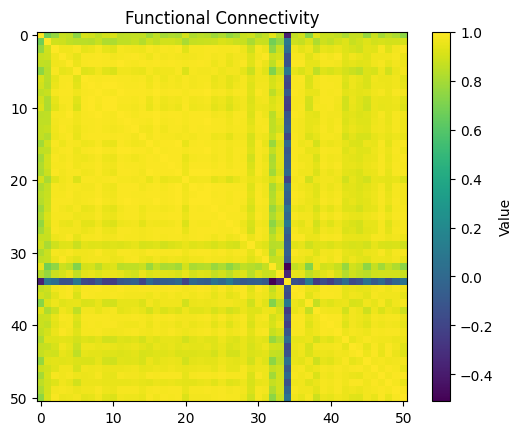

In [5]:
from scipy.stats import pearsonr

fc_matrix = np.zeros((ROI_n, ROI_n))
for i in range(ROI_n):
    fc_matrix[i,i] = 1
    for j in range(i + 1, ROI_n):
        r, _ = pearsonr(ROI_traces[i][0], ROI_traces[j][0])
        fc_matrix[i, j] = r
        fc_matrix[j, i] = r  # symmetric


# FC_Matrix Visualize
plt.imshow(fc_matrix, cmap='viridis')
plt.colorbar(label='Value')
plt.title('Functional Connectivity')
plt.show()

## **3. Create Network**

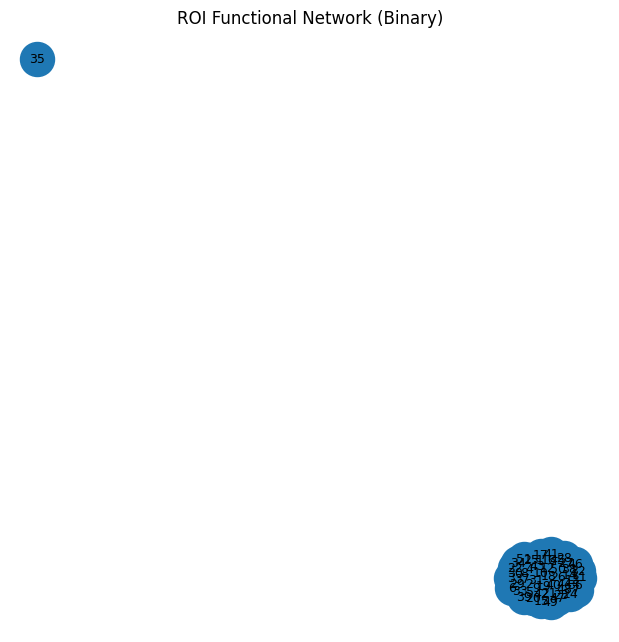

In [6]:
import networkx as nx

threshold = 0.6
G = nx.Graph()
    
# Add nodes
for i in range(ROI_n):
    G.add_node(i, label=ROI_traces[i][1])

# Add edges (upper triangle only)
for i in range(ROI_n):
    for j in range(i + 1, ROI_n):
        if fc_matrix[i, j] > threshold:
            G.add_edge(i, j)

# Visualized
labels = {i: ROI_traces[i][1] for i in range(ROI_n)}
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=42)  # force-directed layout
nx.draw(
    G, pos,
    with_labels=False,      # turn off default labels
    node_size=600
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=9
)

plt.title("ROI Functional Network (Binary)")
plt.show()

## **Community Detection**

{'community_1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51], 'community_2': [35]}


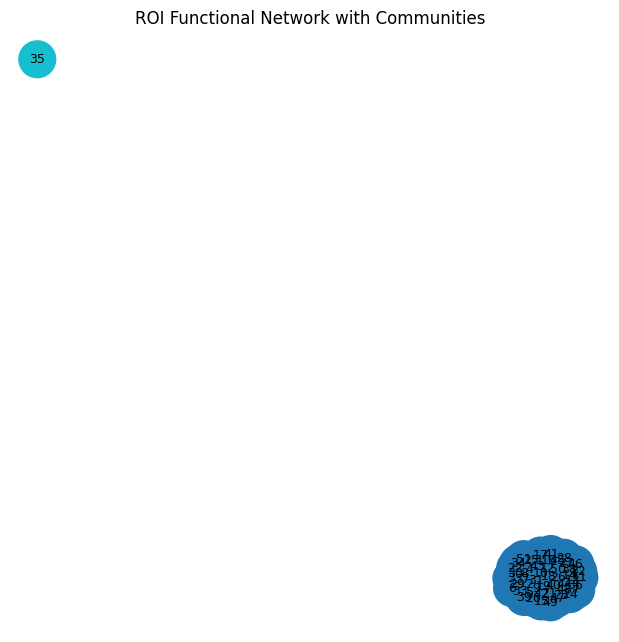

In [7]:
communities = nx.algorithms.community.greedy_modularity_communities(G)

community_dict = {}
for idx, comm in enumerate(communities, start=1):
    roi_names = [ROI_traces[node][1] for node in sorted(comm)]
    community_dict[f"community_{idx}"] = roi_names

print(community_dict)

# Visulize
node_to_community = {}
for comm_id, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = comm_id
node_colors = [node_to_community[i] for i in G.nodes()]
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,   # good discrete colormap
    node_size=700,
    with_labels=False
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=9,
    font_color="black"
)

plt.title("ROI Functional Network with Communities")
plt.axis("off")
plt.show()


# ==========**PCA + Kmean cluster**==========

## **PCA of traces**

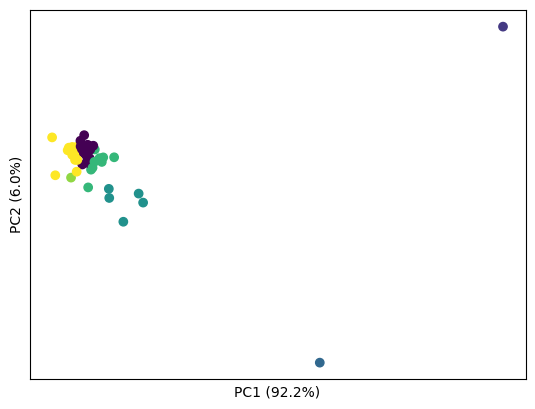


Cluster assignment dictionary:
{0: [3, 6, 9, 13, 14, 18, 19, 20, 22, 23, 24, 25, 27, 28, 29, 31, 32, 36, 37, 40], 1: [35], 2: [2], 3: [43, 45, 46, 47, 49], 4: [4, 16, 26, 30, 38, 42, 44, 48, 50, 51], 5: [1], 6: [5, 7, 8, 10, 11, 12, 15, 17, 21, 33, 34, 39, 41]}


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = roi_traces

pca = PCA(n_components=5)   
X_pca_full = pca.fit_transform(X)

# Clustering-------------------
# sil_scores = []
K_range = range(2, 8)

# for k in K_range:
#     kmeans = KMeans(n_clusters=k, random_state=0)
#     labels = kmeans.fit_predict(X_pca_full)
#     sil_scores.append(silhouette_score(X_pca_full, labels))

# best_k = K_range[np.argmax(sil_scores)]
# print("Best K:", best_k)

n_cluster = 7
# kmeans = KMeans(n_clusters=best_k, random_state=0)
kmeans = KMeans(n_clusters=n_cluster, random_state=0)
cluster_labels = kmeans.fit_predict(X_pca_full)

# PCA for 2D plotting-----------------------------
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

# Plot
plt.figure()
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=cluster_labels
)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.xticks([])
plt.yticks([])
# plt.title(f'PCA Clustering (K={best_k})')
# plt.colorbar(scatter, label='Cluster')
plt.savefig(f'{save_path}/PCA_plot.png',dpi=150)
plt.show()

# -------------------------
# Step 5: Create ROI dictionary
# -------------------------
cluster_dict = {}

# for cluster_id in range(best_k):
#     cluster_dict[cluster_id] = np.where(cluster_labels == cluster_id)[0].tolist()
for cluster_id in range(n_cluster):
    cluster_dict[cluster_id] = (np.where(cluster_labels == cluster_id)[0]+1).tolist()

print("\nCluster assignment dictionary:")
print(cluster_dict)


## **Rearrange traces (order by clusters)**

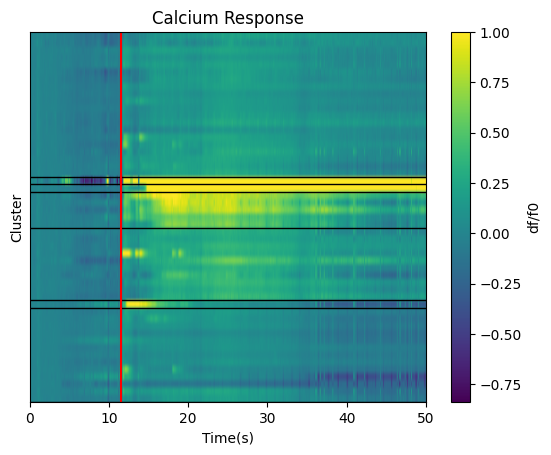

In [77]:
import numpy as np

roi_traces_arranged = []
tick_index = []
tick_label = []

id_acc = 0
for key, roi in cluster_dict.items():
    id_acc+=len(roi)
    tick_index.append(id_acc)
    tick_label.append(f'{key}↑')
    for trace in roi:
        roi_traces_arranged.append(np.load(os.path.join(analyzed_folder, f'Calcium_Trace_ROI[{trace}].npy'))[:500])
        
# Visulize Trace
plt.imshow(roi_traces_arranged, cmap='viridis', aspect='auto', vmax=1, extent=[elapsed_times[0]/1000,elapsed_times[500]/1000, len(roi_traces_arranged), 0])
plt.colorbar(label='df/f0')
plt.xlabel('Time(s)')
plt.ylabel('Cluster')
# plt.yticks(tick_index, tick_label)

plt.yticks([])
for y in tick_index:
    plt.axhline(y=y, color='black', linewidth=1)
plt.axvline(11.5, color='red')
plt.title('Calcium Response')
plt.savefig(f'{save_path}/Trace_plot.png',dpi=150)
plt.show()
        

## **Cluster cell distribution**

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def save_roi_overlay_image(
    image_2d_name,
    label_2d_name,
    cluster_dict,        # <-- ADD THIS
    out_path,
    figsize=(6,6)
):
    image_2d = viewer.layers[image_2d_name].data
    label_2d = viewer.layers[label_2d_name].data
    Y, X = image_2d.shape

    # Fix label orientation if needed
    if label_2d.shape == (X, Y):
        label_2d = label_2d.T

    # Identify ROIs
    roi_ids = np.unique(label_2d)
    roi_ids = roi_ids[roi_ids != 0]

    # -------------------------
    # Create ROI → cluster lookup
    # -------------------------
    roi_to_cluster = {}
    for cluster_id, roi_list in cluster_dict.items():
        for rid in roi_list:
            roi_to_cluster[rid] = cluster_id

    # Precompute contours + centers
    contours = {}
    centers = {}
    for rid in roi_ids:
        m = (label_2d == rid).astype(np.uint8)
        cs = measure.find_contours(m, level=0.5)
        contours[rid] = cs

        ys, xs = np.nonzero(m)
        if len(ys) > 0:
            centers[rid] = (ys.mean(), xs.mean())
        else:
            centers[rid] = (Y/2, X/2)

    # Contrast normalization
    layer = viewer.layers[image_2d_name]
    vmin, vmax = layer.contrast_limits
    frame_norm = np.clip((image_2d - vmin) / (vmax - vmin + 1e-9), 0, 1)

    cmap = plt.get_cmap("viridis")
    n_clusters = len(cluster_dict)
    norm = plt.Normalize(vmin=0, vmax=n_clusters - 1)

    # Create clean borderless figure
    fig = plt.figure(figsize=figsize, dpi=120)
    fig.patch.set_facecolor("black")
    ax = fig.add_axes([0,0,1,1])
    ax.set_axis_off()

    ax.imshow(frame_norm, cmap="gray", vmin=0, vmax=1, interpolation="nearest")

    # -------------------------
    # Draw ROIs by cluster color
    # -------------------------
    for rid in roi_ids:

        cluster_id = roi_to_cluster.get(rid, None)

        if cluster_id is None:
            color = (0.5, 0.5, 0.5)
        else:
            # cluster_id is 1-based → convert to 0-based
            color = cmap(norm(cluster_id))

        for poly in contours[rid]:
            ax.plot(poly[:,1], poly[:,0], linewidth=0.8, color=color)

    fig.savefig(out_path, dpi=200, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    print(f"Saved labeled overlay image → {out_path}")


image_2d = "Green max-proj"
label_2d = "Manual ROI (loaded)"

save_roi_overlay_image(image_2d, label_2d, cluster_dict,f"{output_path}/Cluster_Labeled.png")

Saved labeled overlay image → C:\Users\nick1\Desktop\2P_image\Debi_Data\Analyzed\Slide\Streamtodisk-1769166699-997/Cluster_Labeled.png
